# Handwritten Digit Classification
![](https://editor.analyticsvidhya.com/uploads/95577cnn2.gif)

## 📦 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

## 📥 2. Load MNIST Handwritten Digit Recognition Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(x_train.shape)  # (60000, 28, 28)

(60000, 28, 28)


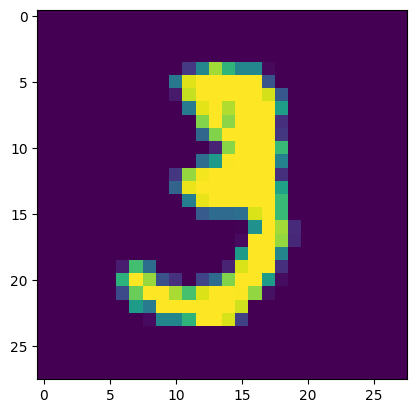

In [4]:
x_train[10]
plt.imshow(x_train[10])

In [6]:
print(y_train[10])

3


## 🎨 3. Visualization of Sample Data

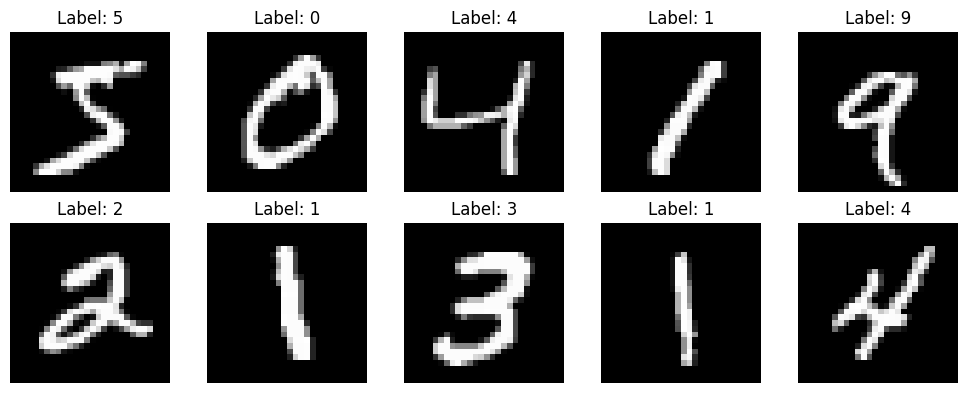

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing (Flatten + Normalize)

![](https://lh3.googleusercontent.com/proxy/wNLhUqpOpBGPmfUIopgsshTtyJHh8VnAl5Ef4Koz9vXhLQ5osTQBwi5dTV-SbeL7NV6mRN_bOM8OO2bFL8Np3AQQTjdKm3Qb5MNhmB3Ts0E954BJJl-cjHp5f1c6znVIahNpuA)

![](https://www.superdatascience.com/wp-content/uploads/73_blog_image_1.png)

In [ ]:
x_train = x_train.reshape(60000, 28*28).astype("float32") / 255
x_test = x_test.reshape(10000, 28*28).astype("float32") / 255

## 🏗️ 5. Build ANN Model

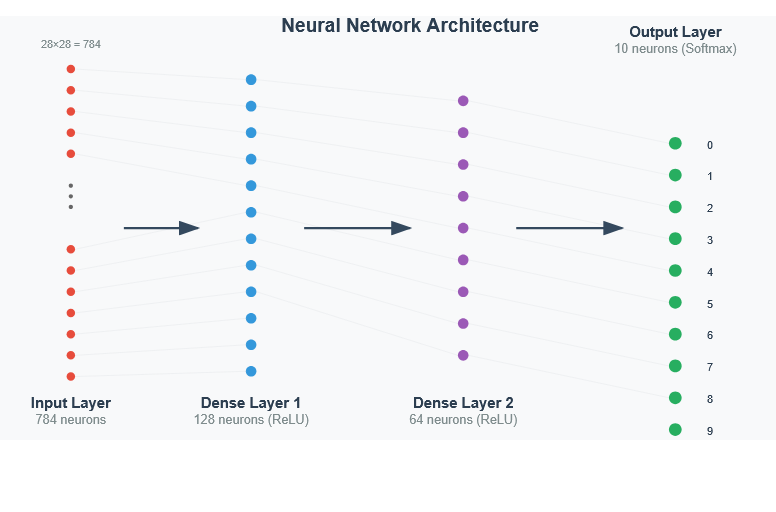

In [ ]:
# hidden layers -> use relu
# output layer -> use sigmoid(for binary classification) or softmax(for multiclass classification)
# for each layer use number of neuron = 2^n e.g. 2^9 = 515, 2^7=128 etc.

model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


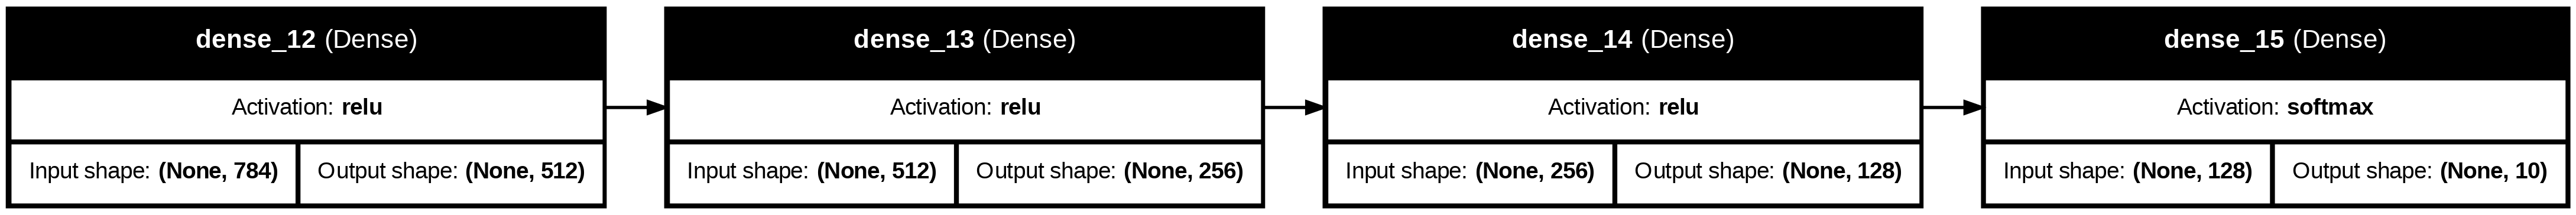

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='neural_network_plot.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='LR', # 'TB' for top-to-bottom layout; 'LR' for left-to-right layout
    show_layer_activations=True
)

## ⚙️ 6. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

## 🚀 7. Train Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9252 - loss: 0.2511 - val_accuracy: 0.9655 - val_loss: 0.1148
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9731 - loss: 0.0893 - val_accuracy: 0.9675 - val_loss: 0.1031
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9816 - loss: 0.0586 - val_accuracy: 0.9718 - val_loss: 0.0945
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9869 - loss: 0.0414 - val_accuracy: 0.9762 - val_loss: 0.0812
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9723 - val_loss: 0.1026
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.9774 - val_loss: 0.0938
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9920 - loss: 0.0237 - val_accuracy: 0.9747 - val_loss: 0.0950
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9936 - loss: 0.0193 - val_accu

## 📈 8. Training Visualization

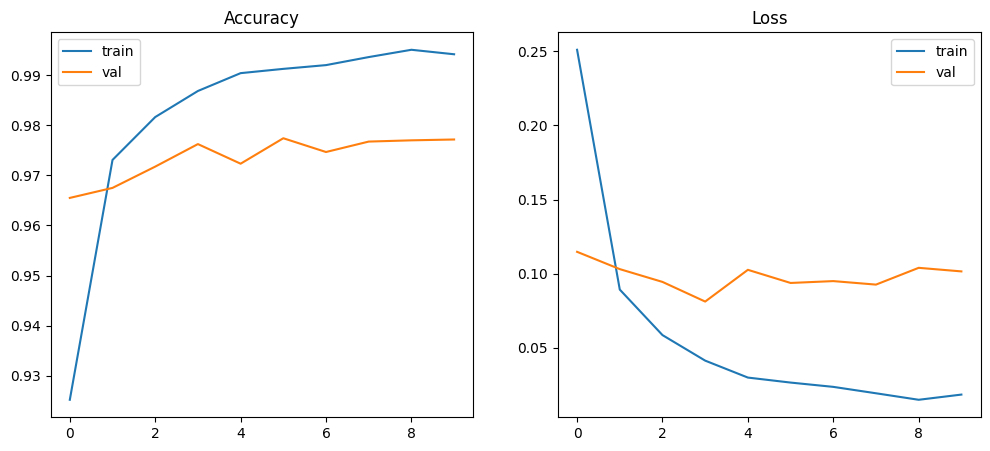

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

## 🔮 9. Predictions Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


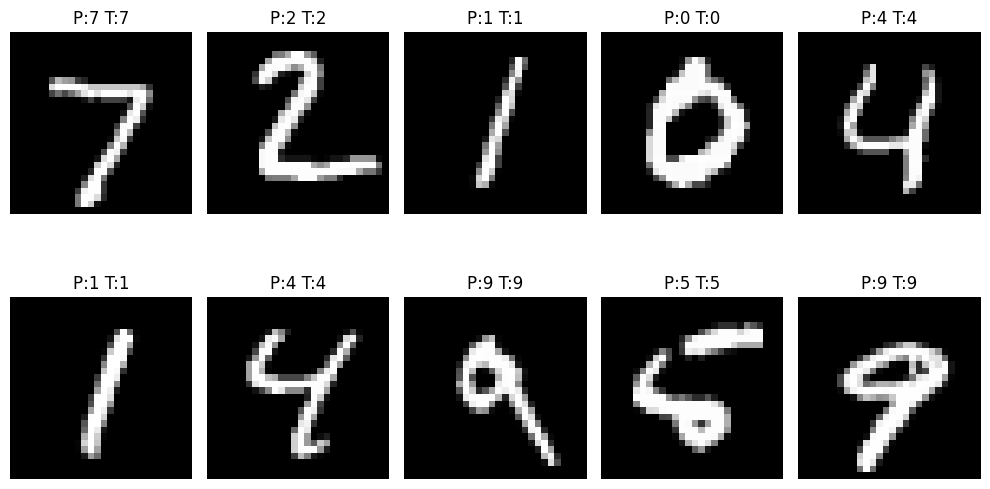

In [ ]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"P:{pred_label} T:{true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 📊 10. Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9803 - loss: 0.0825
Test Accuracy: 0.9803000092506409


In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.96      0.97       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.99      0.98      1028
           8       0.99      0.97      0.98       974
           9       0.97      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
x1 = 162 # height
x2 = 2 # color

w1 = 0.4
w2 = 0.7

b = 10

y = w1 * x1 + w2 * x2 + b

print(y)
#

76.2


In [ ]:
y = z = 76.2 -> step function (activation funtion) -> 1 (Asian)

y = -3.7 -> 0

In [ ]:
def step_function(value):
  if value > 0:
    return 1
  else:
    return 0

In [ ]:
step_function(20)

1

In [ ]:
perceptron -> linear proble

multiple perceptron -> neural network -> non linear problem

In [ ]:
relue (0, max) -

![](![image.png]())

![](https://bait509-ubc.github.io/BAIT509/_images/train-valid-test-split.png)

In [ ]:
student - teacher - book example - 15 ->